# Analyse av manual review-tags i mappings-JSON-filer

Les alle JSON-filer fra `mappings*`-mapper og lag plots for review-analyse.

**Sett `ROOT` til mappen der `mappings`-undermappene dine ligger.**

In [ ]:
from pathlib import Path

# ── KONFIGURASJON — endre disse ────────────────────────────────────
ROOT    = Path("../data/mappings/acc_mappings")
OUT_DIR = Path("plot_exports")
TOP_N   = 20

INCLUDE_FOLDERS = {"acc_mappings_cox", "acc_mappings_hex", "acc_mappings_isx",
                   "acc_mappings_obx", "acc_mappings_stx"}
# ────────────────────────────────────────────────────────────────────

OUT_DIR.mkdir(parents=True, exist_ok=True)
print(f"Root: {ROOT.resolve()}")
print(f"Output: {OUT_DIR.resolve()}")

Root: /Users/fredrikfuglerudflugstad/Library/Mobile Documents/com~apple~CloudDocs/Skole/NTNU/Industriell Økonomi og Teknologiledelse/10. Semester/Equity_Quality_Under_Uncertainty/data/mappings/acc_mappings
Output: /Users/fredrikfuglerudflugstad/Library/Mobile Documents/com~apple~CloudDocs/Skole/NTNU/Industriell Økonomi og Teknologiledelse/10. Semester/Equity_Quality_Under_Uncertainty/manual_review/plot_exports


## Importer og plot-tema

In [6]:
import json
import re
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.ticker import FuncFormatter

try:
    import seaborn as sns
    HAS_SEABORN = True
except ImportError:
    HAS_SEABORN = False

THEME = {
    "figure.facecolor": "#f5f5f7",
    "axes.facecolor": "#ebedf2",
    "axes.edgecolor": "#c9ced8",
    "axes.labelcolor": "#2f3b4a",
    "axes.titlecolor": "#1f2937",
    "axes.grid": True,
    "grid.color": "#b8c0cc",
    "grid.linestyle": "--",
    "grid.alpha": 0.45,
    "font.family": "DejaVu Sans",
    "font.size": 11,
    "axes.titlesize": 17,
    "axes.titleweight": "bold",
    "axes.labelsize": 12,
    "xtick.color": "#435165",
    "ytick.color": "#435165",
    "legend.frameon": False,
    "figure.autolayout": False,
}

PALETTE = {
    "blue":   "#4C78A8",
    "teal":   "#54A6A6",
    "green":  "#72B7B2",
    "orange": "#F2A65A",
    "red":    "#D95F5F",
    "gold":   "#E9C46A",
    "navy":   "#2A4E6E",
    "slate":  "#7B8BA3",
}

TAG_COLORS = {
    "CR:c":  PALETTE["red"],
    "CR:nc": PALETTE["orange"],
    "R:c":   PALETTE["blue"],
    "R:nc":  PALETTE["teal"],
    "none":  PALETTE["slate"],
}

plt.rcParams.update(THEME)
if HAS_SEABORN:
    sns.set_theme(style="darkgrid", rc=THEME)

print("Tema lastet.")

Tema lastet.


## Hjelpefunksjoner

In [7]:
def fmt_int(x, pos=None):
    try:
        return f"{int(x):,}"
    except Exception:
        return str(x)

def style_axis(ax, title, xlabel=None, ylabel=None):
    ax.set_title(title, pad=12)
    if xlabel:
        ax.set_xlabel(xlabel)
    if ylabel:
        ax.set_ylabel(ylabel)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.yaxis.set_major_formatter(FuncFormatter(fmt_int))

def add_bar_labels(ax, fmt="{:,.0f}", pad_frac=0.01):
    heights = [p.get_height() for p in ax.patches]
    ymax = max(heights, default=0)
    offset = ymax * pad_frac if ymax > 0 else 0.1
    for patch in ax.patches:
        v = patch.get_height()
        if v > 0:
            ax.text(
                patch.get_x() + patch.get_width() / 2,
                v + offset,
                fmt.format(v),
                ha="center", va="bottom",
                fontsize=10, color="#253243", fontweight="semibold",
            )

def extract_tag(notes: str) -> str:
    if not notes:
        return "none"
    m = re.search(r'\b(CR:nc|CR:c|R:nc|R:c)\b', notes, re.IGNORECASE)
    if m:
        return m.group(1).upper().replace("NC", "nc").replace(":C", ":c")
    return "none"

def extract_cr_severity(notes: str):
    if not notes:
        return None
    m = re.search(r'CR:c\|(\w+)', notes, re.IGNORECASE)
    return m.group(1).lower() if m else None

def extract_cr_reason(notes: str):
    if not notes:
        return None
    m = re.search(r'CR:c\|\w+\|(\w+)', notes, re.IGNORECASE)
    return m.group(1).lower() if m else None

print("Hjelpefunksjoner definert.")

Hjelpefunksjoner definert.


## Last inn data fra mappings-mapper

In [9]:
def load_all_mappings(root: Path) -> pd.DataFrame:
    records = []
    mapping_dirs = [d for d in root.iterdir() 
                    if d.is_dir() and d.name in INCLUDE_FOLDERS]
    
    if not mapping_dirs:
        raise FileNotFoundError(f"Found no mapping folders under {root}.")

    print(f"Found {len(mapping_dirs)} mapping folders:")
    for folder in sorted(mapping_dirs):
        json_files = list(folder.glob("*.json"))  # glob i stedet for rglob
        print(f"  {folder.name}: {len(json_files)} JSON-filer")
        for jf in json_files:
            try:
                data = json.loads(jf.read_text(encoding="utf-8"))
            except Exception:
                continue
            company = jf.stem
            for var_obj in data.get("variables", []):
                notes = var_obj.get("notes", "") or ""
                tag   = extract_tag(notes)
                records.append({
                    "folder":   folder.name,
                    "company":  company,
                    "variable": var_obj.get("variable", "UNKNOWN"),
                    "notes":    notes,
                    "tag":      tag,
                    "needs_mr": bool(var_obj.get("needs_manual_review", False)),
                    "has_review":    tag != "none",
                    "is_confirmed":  tag in ("CR:c", "R:c"),
                    "is_cost_ratio": tag.startswith("CR"),
                })

    df = pd.DataFrame(records)
    print(f"\nTotalt {len(df)} rader fra {df['company'].nunique()} selskaper.")
    return df

df = load_all_mappings(ROOT)

Found 5 mapping folders:
  acc_mappings_cox: 89 JSON-filer
  acc_mappings_hex: 121 JSON-filer
  acc_mappings_isx: 22 JSON-filer
  acc_mappings_obx: 148 JSON-filer
  acc_mappings_stx: 264 JSON-filer

Totalt 5152 rader fra 644 selskaper.


## Sammendrag

In [10]:
print('\n' + '═'*55)
print('  SAMMENDRAG')
print('═'*55)
print(f"  Totale variabel-oppføringer : {len(df):,}")
print(f"  Unike selskaper             : {df['company'].nunique():,}")
print(f"  Unike mapper                : {df['folder'].nunique():,}")
print()
tag_counts = df['tag'].value_counts()
for tag in ['CR:c', 'CR:nc', 'R:c', 'R:nc', 'none']:
    n = tag_counts.get(tag, 0)
    pct = n / len(df) * 100
    print(f"  {tag:<8} : {n:>5,}  ({pct:5.1f}%)")
print()
print(f"  needs_manual_review=True    : {df['needs_mr'].sum():,}")
print('═'*55)


═══════════════════════════════════════════════════════
  SAMMENDRAG
═══════════════════════════════════════════════════════
  Totale variabel-oppføringer : 5,152
  Unike selskaper             : 644
  Unike mapper                : 5

  CR:c     :     0  (  0.0%)
  CR:nc    :     0  (  0.0%)
  R:c      :   360  (  7.0%)
  R:nc     :   118  (  2.3%)
  none     : 4,674  ( 90.7%)

  needs_manual_review=True    : 1
═══════════════════════════════════════════════════════


## Plot 2 — Fordeling av review-tags

- **CR:c / CR:nc** → unike selskaper (ett selskap telles én gang uansett antall flaggede variabler)
- **R:c / R:nc** → antall tilfeller (hvert enkelt sted review er gjort)

/var/folders/6l/ncl3jvl12ks8dlc1p950qzsh0000gn/T/ipykernel_71426/469182244.py:91: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


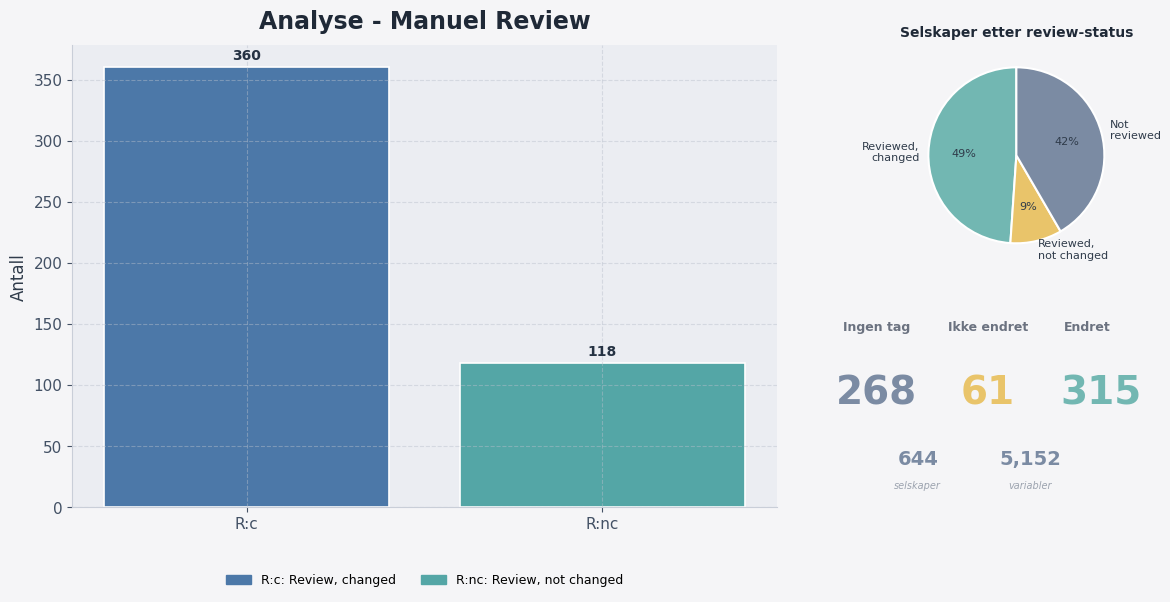

In [14]:
tag_order3 = ['R:c', 'R:nc']
counts3 = {}

# R:c og R:nc — antall tilfeller (rader)
for tag in ['R:c', 'R:nc']:
    counts3[tag] = int((df['tag'] == tag).sum())

# Ingen tag — selskaper som ALDRI har noen tag
r_c_companies   = set(df[df['tag'] == 'R:c']['company'].unique())
r_nc_companies  = set(df[df['tag'] == 'R:nc']['company'].unique())
confirmed_companies = r_c_companies

no_tag_companies = len(
    set(df['company'].unique()) - set(df[df['tag'] != 'none']['company'].unique())
)

not_changed_companies = len(r_nc_companies - confirmed_companies)

# Sektordiagram-verdier
pie_values = [len(confirmed_companies), not_changed_companies, no_tag_companies]
pie_labels = ['Reviewed,\nchanged', 'Reviewed,\nnot changed', 'Not\nreviewed']
pie_colors = [PALETTE['green'], PALETTE['gold'], PALETTE['slate']]

values3 = [counts3[t] for t in tag_order3]

fig = plt.figure(figsize=(14, 6))
gs  = fig.add_gridspec(2, 2, width_ratios=[2.5, 1], height_ratios=[1, 1], hspace=0.1)

ax      = fig.add_subplot(gs[:, 0])
ax_pie  = fig.add_subplot(gs[0, 1])
ax_info = fig.add_subplot(gs[1, 1])

# ── Hovedplot (venstre) ────────────────────────────────────────────────────
ax.bar(tag_order3, values3, color=[TAG_COLORS[t] for t in tag_order3],
       edgecolor='white', linewidth=1.2)
add_bar_labels(ax)
style_axis(ax, 'Analyse - Manuel Review', ylabel='Antall')

legend_info = {
    'R:c':  'Review, changed',
    'R:nc': 'Review, not changed',
}
patches = [mpatches.Patch(color=TAG_COLORS[t], label=f"{t}: {legend_info[t]}") 
           for t in tag_order3]
ax.legend(handles=patches, loc='upper center', bbox_to_anchor=(0.5, -0.12),
          ncol=2, fontsize=9)

# ── Sektordiagram (øvre høyre) ────────────────────────────────────────────
ax_pie.pie(
    pie_values, labels=pie_labels, colors=pie_colors,
    autopct='%1.0f%%', startangle=90,
    textprops={'fontsize': 8, 'color': '#2f3b4a'},
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5},
)
ax_pie.set_title('Selskaper etter review-status', fontsize=10, fontweight='bold',
                 color='#1f2937', pad=6)

# ── Infoboks (nedre høyre) ────────────────────────────────────────────────
ax_info.axis('off')

total_companies = len(set(df['company'].unique()))
total_variables = len(df)

ax_info.text(0.005, 0.82, 'Ingen tag', ha='center', va='center',
             fontsize=9, fontweight='bold', color='#6b7280', transform=ax_info.transAxes)
ax_info.text(0.005, 0.52, f'{no_tag_companies:,}', ha='center', va='center',
             fontsize=28, fontweight='bold', color=PALETTE['slate'], transform=ax_info.transAxes)

ax_info.text(0.40, 0.82, 'Ikke endret', ha='center', va='center',
             fontsize=9, fontweight='bold', color='#6b7280', transform=ax_info.transAxes)
ax_info.text(0.40, 0.52, f'{not_changed_companies:,}', ha='center', va='center',
             fontsize=28, fontweight='bold', color=PALETTE['gold'], transform=ax_info.transAxes)

ax_info.text(0.75, 0.82, 'Endret', ha='center', va='center',
             fontsize=9, fontweight='bold', color='#6b7280', transform=ax_info.transAxes)
ax_info.text(0.80, 0.52, f'{len(confirmed_companies):,}', ha='center', va='center',
             fontsize=28, fontweight='bold', color=PALETTE['green'], transform=ax_info.transAxes)

ax_info.text(0.15, 0.22, f'{total_companies:,}', ha='center', va='center',
             fontsize=14, fontweight='bold', color=PALETTE['slate'], transform=ax_info.transAxes)
ax_info.text(0.15, 0.10, 'selskaper', ha='center', va='center',
             fontsize=7, color='#9ca3af', style='italic', transform=ax_info.transAxes)

ax_info.text(0.55, 0.22, f'{total_variables:,}', ha='center', va='center',
             fontsize=14, fontweight='bold', color=PALETTE['slate'], transform=ax_info.transAxes)
ax_info.text(0.55, 0.10, 'variabler', ha='center', va='center',
             fontsize=7, color='#9ca3af', style='italic', transform=ax_info.transAxes)

for spine in ax_info.spines.values():
    spine.set_visible(False)
fig.tight_layout()
fig.savefig(OUT_DIR / '3_tag_distribution.png', dpi=150)
plt.show()

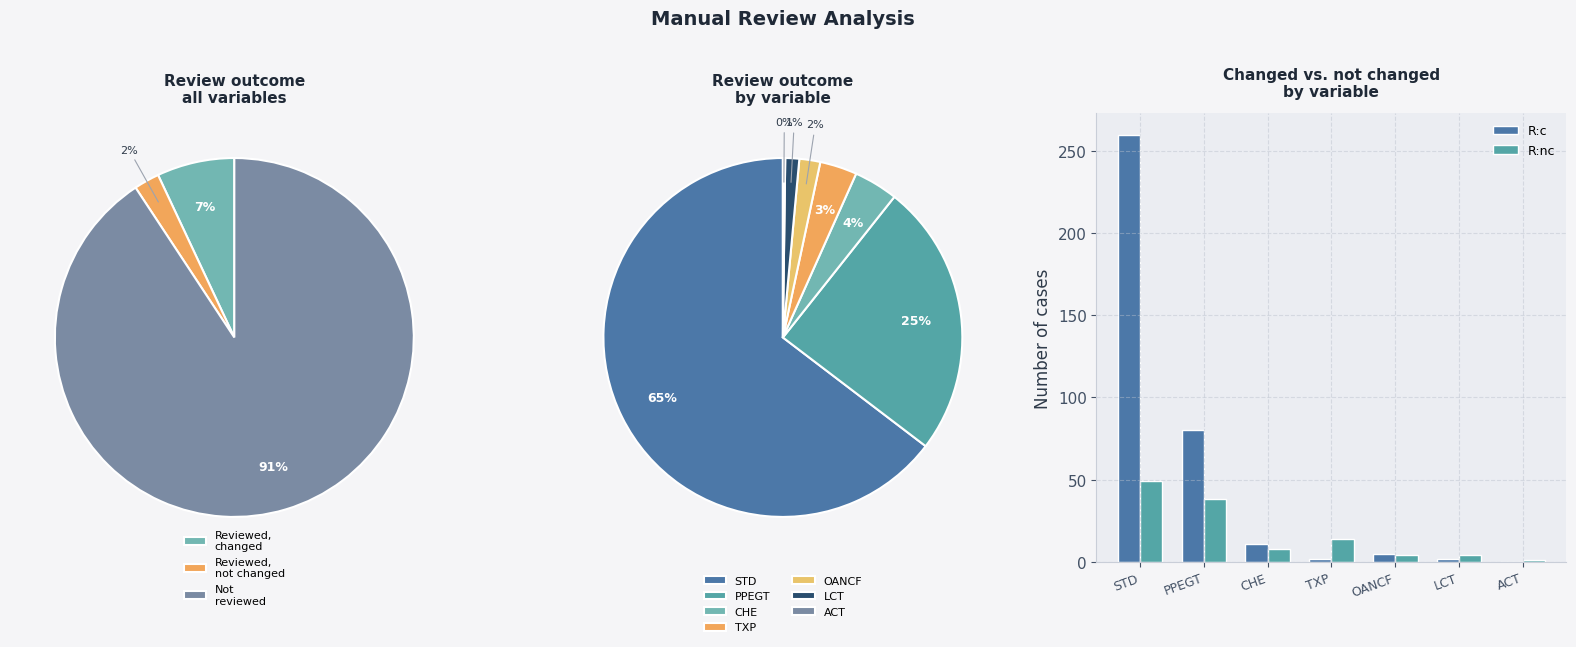

In [15]:
# ── Data ──────────────────────────────────────────────────────────────────
tag_priority = {'CR:c': 3, 'R:c': 2, 'CR:nc': 1, 'R:nc': 1, 'none': 0}
df['tag_rank'] = df['tag'].map(tag_priority)
top_tag = df.groupby(['company', 'variable'])['tag_rank'].max().reset_index()
top_tag['tag_group'] = top_tag['tag_rank'].map({
    3: 'changed', 2: 'changed', 1: 'not_changed', 0: 'not_reviewed'
})

# R-only version for first pie (exclude CR)
r_top = df[df['tag'].isin(['R:c', 'R:nc', 'none'])].copy()
r_top['tag_rank'] = r_top['tag'].map({'R:c': 2, 'R:nc': 1, 'none': 0})
r_top_tag = r_top.groupby(['company', 'variable'])['tag_rank'].max().reset_index()
r_top_tag['tag_group'] = r_top_tag['tag_rank'].map({
    2: 'changed', 1: 'not_changed', 0: 'not_reviewed'
})

changed_n      = int((r_top_tag['tag_group'] == 'changed').sum())
not_changed_n  = int((r_top_tag['tag_group'] == 'not_changed').sum())
not_reviewed_n = int((r_top_tag['tag_group'] == 'not_reviewed').sum())

pie1_values = [changed_n, not_changed_n, not_reviewed_n]
pie1_labels = ['Reviewed,\nchanged', 'Reviewed,\nnot changed', 'Not\nreviewed']
pie1_colors = [PALETTE['green'], PALETTE['orange'], PALETTE['slate']]

r_only = df[df['tag'].isin(['R:c', 'R:nc'])].copy()
r_var_counts = r_only.groupby(['variable', 'tag']).size().unstack(fill_value=0)
r_var_counts['total'] = r_var_counts.sum(axis=1)
r_var_counts = r_var_counts.sort_values('total', ascending=False)

pie2_values = r_var_counts.get('R:c', pd.Series(dtype=int)).reindex(r_var_counts.index, fill_value=0).values + \
              r_var_counts.get('R:nc', pd.Series(dtype=int)).reindex(r_var_counts.index, fill_value=0).values
pie2_labels = r_var_counts.index.tolist()
pie2_colors = [PALETTE['blue'], PALETTE['teal'], PALETTE['green'],
               PALETTE['orange'], PALETTE['gold'], PALETTE['navy'], PALETTE['slate']][:len(pie2_labels)]

r_c_per_var  = r_var_counts.get('R:c',  pd.Series(dtype=int)).reindex(r_var_counts.index, fill_value=0)
r_nc_per_var = r_var_counts.get('R:nc', pd.Series(dtype=int)).reindex(r_var_counts.index, fill_value=0)

# ── Figure ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 6))

# ── Plot 1 ─────────────────────────────────────────────────────────────────
result1 = axes[0].pie(pie1_values, colors=pie1_colors, autopct=None, labels=None,
                      startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
wedges1 = result1[0]
total1  = sum(pie1_values)
threshold = 0.03
for wedge, val in zip(wedges1, pie1_values):
    pct   = val / total1
    angle = (wedge.theta1 + wedge.theta2) / 2
    rad   = np.deg2rad(angle)
    if pct >= threshold:
        t = axes[0].text(0.75*np.cos(rad), 0.75*np.sin(rad), f'{pct*100:.0f}%',
                         ha='center', va='center', fontsize=9, 
                         fontweight='semibold', zorder=10)
        t.set_color('white')
    else:
        axes[0].annotate(
            f'{pct*100:.0f}%',
            xy=(0.85*np.cos(rad), 0.85*np.sin(rad)),
            xytext=(1.2*np.cos(rad), 1.2*np.sin(rad)),
            ha='center', va='center', fontsize=8, color='#2f3b4a',
            arrowprops=dict(arrowstyle='-', color='#9ca3af', lw=0.8),
        )
axes[0].legend(labels=pie1_labels, loc='lower center', bbox_to_anchor=(0.5, -0.12),
               ncol=1, fontsize=8, frameon=False)
axes[0].set_title('Review outcome\nall variables', fontsize=11,
                  fontweight='bold', color='#1f2937', pad=8)

# ── Plot 2 ─────────────────────────────────────────────────────────────────
result2 = axes[1].pie(pie2_values, colors=pie2_colors, autopct=None, labels=None,
                      startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
wedges2 = result2[0]
total2  = sum(pie2_values)
threshold = 0.03
for wedge, val in zip(wedges2, pie2_values):
    pct   = val / total2
    angle = (wedge.theta1 + wedge.theta2) / 2
    rad   = np.deg2rad(angle)
    if pct >= threshold:
        t = axes[1].text(0.75*np.cos(rad), 0.75*np.sin(rad), f'{pct*100:.0f}%',
                         ha='center', va='center', fontsize=9, fontweight='semibold', zorder=10)
        t.set_color('white')
    else:
        axes[1].annotate(
            f'{pct*100:.0f}%',
            xy=(0.85*np.cos(rad), 0.85*np.sin(rad)),
            xytext=(1.2*np.cos(rad), 1.2*np.sin(rad)),
            ha='center', va='center', fontsize=8, color='#2f3b4a',
            arrowprops=dict(arrowstyle='-', color='#9ca3af', lw=0.8),
        )
axes[1].legend(labels=pie2_labels, loc='lower center', bbox_to_anchor=(0.5, -0.18),
               ncol=2, fontsize=8, frameon=False)
axes[1].set_title('Review outcome\nby variable', fontsize=11,
                  fontweight='bold', color='#1f2937', pad=8)
# ── Plot 3 ─────────────────────────────────────────────────────────────────
x     = np.arange(len(r_var_counts.index))
width = 0.35
axes[2].bar(x - width/2, r_c_per_var.values,  width, label='R:c',  color=PALETTE['blue'], edgecolor='white')
axes[2].bar(x + width/2, r_nc_per_var.values, width, label='R:nc', color=PALETTE['teal'], edgecolor='white')
style_axis(axes[2], 'Changed vs. not changed\nby variable', ylabel='Number of cases')
axes[2].title.set_fontsize(11)
axes[2].set_xticks(x)
axes[2].set_xticklabels(r_var_counts.index.tolist(), rotation=20, ha='right', fontsize=9)
axes[2].legend(fontsize=9)

fig.suptitle('Manual Review Analysis', fontsize=14, fontweight='bold', color='#1f2937', y=1.01)
fig.tight_layout()
fig.savefig(OUT_DIR / '8_review_pie_analysis.png', dpi=150)
plt.show()

## Plot 4 — Companies with Tag

/var/folders/6l/ncl3jvl12ks8dlc1p950qzsh0000gn/T/ipykernel_71426/3535596746.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(pct.index, rotation=20, ha='right')


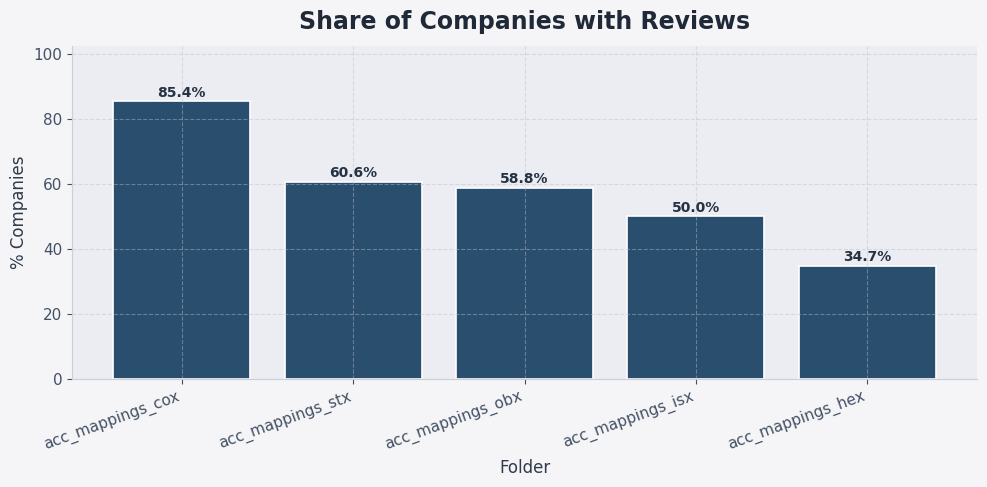

In [16]:
reviewed_per_folder = df[df['has_review']].groupby('folder')['company'].nunique()
total_per_folder    = df.groupby('folder')['company'].nunique()
pct = (reviewed_per_folder / total_per_folder * 100).fillna(0).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(pct.index, pct.values, color=PALETTE['navy'], edgecolor='white', linewidth=1.2)
for patch, val in zip(ax.patches, pct.values):
    ax.text(patch.get_x() + patch.get_width()/2, val+0.5, f'{val:.1f}%',
            ha='center', va='bottom', fontsize=10, color='#253243', fontweight='semibold')
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x:.0f}%'))
style_axis(ax, 'Share of Companies with Reviews', xlabel='Folder', ylabel='% Companies')
ax.set_xticklabels(pct.index, rotation=20, ha='right')
ax.set_ylim(0, min(pct.max()*1.2, 110))
fig.tight_layout()
fig.savefig(OUT_DIR / '4_review_rate_per_folder.png', dpi=150)
plt.show()

## LLM Performance - Analysis

In [19]:
import json
import re
from pathlib import Path
from collections import defaultdict

# ── Config ─────────────────────────────────────────────────────────────────
ROOT = Path("../data/mappings/acc_mappings")

INCLUDE_FOLDERS = {"acc_mappings_cox", "acc_mappings_hex", "acc_mappings_isx",
                   "acc_mappings_obx", "acc_mappings_stx"}

EXCHANGE_NAMES = {
    'acc_mappings_obx': 'Oslo Børs',
    'acc_mappings_stx': 'Nasdaq Stockholm',
    'acc_mappings_isx': 'Nasdaq Iceland',
    'acc_mappings_cox': 'Nasdaq Copenhagen',
    'acc_mappings_hex': 'Nasdaq Helsinki'
}

TARGET_TAGS = ['R:c', 'R:nc']

# ── Exact tag matching ─────────────────────────────────────────────────────
def find_tags(notes, target_tags):
    matched = []
    for tag in target_tags:
        pattern = r'(?<![A-Za-z:])' + re.escape(tag) + r'(?![A-Za-z:|])'
        if re.search(pattern, notes):
            matched.append(tag)
    return matched

# ── Priority logic — R:c suppresses R:nc ──────────────────────────────────
def apply_priority(matched):
    if 'R:c' in matched:
        return [t for t in matched if t != 'R:nc']
    return matched

# ── Count with priority logic per exchange ─────────────────────────────────
counts_total = {tag: 0 for tag in TARGET_TAGS}
counts_per_exchange = {ex: {tag: 0 for tag in TARGET_TAGS}
                       for ex in EXCHANGE_NAMES.values()}

remaining_multi = []

for folder in ROOT.iterdir():
    if not folder.is_dir() or folder.name not in INCLUDE_FOLDERS:
        continue
    exchange = EXCHANGE_NAMES[folder.name]
    for jf in folder.glob('*.json'):
        try:
            data = json.loads(jf.read_text(encoding='utf-8'))
        except Exception:
            continue
        for var_obj in data.get('variables', []):
            notes = var_obj.get('notes', '') or ''
            matched = find_tags(notes, TARGET_TAGS)

            if not matched:
                continue

            matched = apply_priority(matched)

            if len(matched) > 1:
                remaining_multi.append({
                    'folder': folder.name,
                    'file': jf.stem,
                    'variable': var_obj.get('variable', ''),
                    'matched_tags': matched,
                    'notes': notes[:300]
                })

            for tag in matched:
                counts_total[tag] += 1
                counts_per_exchange[exchange][tag] += 1

# ── Print total ────────────────────────────────────────────────────────────
print("=" * 55)
print("FULL TAG COUNTS — TOTAL")
print(f"{'Tag':<35} {'Count':>8}")
print('-' * 45)
for tag, count in counts_total.items():
    print(f"{tag:<35} {count:>8}")
print('-' * 45)
print(f"{'Total':<35} {sum(counts_total.values()):>8}")

# ── Print per exchange ─────────────────────────────────────────────────────
exchanges = list(EXCHANGE_NAMES.values())
col_w = 14

print()
print("=" * (35 + col_w * (len(exchanges) + 1)))
print("FULL TAG COUNTS — PER EXCHANGE")
print()
header = f"{'Tag':<35}" + "".join(f"{ex:>{col_w}}" for ex in exchanges) + f"{'Total':>{col_w}}"
print(header)
print('-' * (35 + col_w * (len(exchanges) + 1)))
for tag in TARGET_TAGS:
    row_total = sum(counts_per_exchange[ex][tag] for ex in exchanges)
    row = f"{tag:<35}" + "".join(f"{counts_per_exchange[ex][tag]:>{col_w}}"
                                  for ex in exchanges) + f"{row_total:>{col_w}}"
    print(row)
print('-' * (35 + col_w * (len(exchanges) + 1)))
grand_total = sum(counts_total.values())
totals = f"{'Total':<35}" + "".join(
    f"{sum(counts_per_exchange[ex][tag] for tag in TARGET_TAGS):>{col_w}}"
    for ex in exchanges) + f"{grand_total:>{col_w}}"
print(totals)

# ── Verification ───────────────────────────────────────────────────────────
print()
print("=" * 55)
print("VERIFICATION")
print(f"  R:c  count:                     {counts_total['R:c']:>6}")
print(f"  R:nc count:                     {counts_total['R:nc']:>6}")
print()
print(f"  Remaining multi-tag cases:      {len(remaining_multi):>6}",
      "✅" if len(remaining_multi) == 0 else "⚠️  — sjekk nedenfor")

if remaining_multi:
    print()
    for case in remaining_multi[:10]:
        print(f"    {case['folder']} | {case['file']} | {case['variable']}")
        print(f"    Tags:  {case['matched_tags']}")
        print(f"    Notes: {case['notes']}")
        print()
    if len(remaining_multi) > 10:
        print(f"  ... og {len(remaining_multi) - 10} flere tilfeller")

FULL TAG COUNTS — TOTAL
Tag                                    Count
---------------------------------------------
R:c                                      360
R:nc                                     118
---------------------------------------------
Total                                    478

FULL TAG COUNTS — PER EXCHANGE

Tag                                     Oslo BørsNasdaq StockholmNasdaq IcelandNasdaq CopenhagenNasdaq Helsinki         Total
-----------------------------------------------------------------------------------------------------------------------
R:c                                            79           167             8            66            40           360
R:nc                                           25            35             3            48             7           118
-----------------------------------------------------------------------------------------------------------------------
Total                                         104           202  

In [20]:
# ── Changed vs unchanged per variable ─────────────────────────────────────
C_TAGS  = [t for t in TARGET_TAGS if ':c' in t and 'nc' not in t]
NC_TAGS = [t for t in TARGET_TAGS if t.endswith(':nc')]

print()
print("=" * 45)
print("CHANGED VS UNCHANGED PER VARIABLE")
print(f"{'Variable':<20} {'Changed':>10} {'Unchanged':>10} {'Total':>10}")
print('-' * 45)

var_c  = defaultdict(int)
var_nc = defaultdict(int)

for folder in ROOT.iterdir():
    if not folder.is_dir() or folder.name not in INCLUDE_FOLDERS:
        continue
    for jf in folder.rglob('*.json'):
        try:
            data = json.loads(jf.read_text(encoding='utf-8'))
        except Exception:
            continue
        for var_obj in data.get('variables', []):
            notes    = var_obj.get('notes', '') or ''
            variable = var_obj.get('variable', 'UNKNOWN')
            matched  = find_tags(notes, TARGET_TAGS)
            if not matched:
                continue
            matched = apply_priority(matched)
            for tag in matched:
                if tag in C_TAGS:
                    var_c[variable] += 1
                elif tag in NC_TAGS:
                    var_nc[variable] += 1

all_vars = sorted(set(list(var_c.keys()) + list(var_nc.keys())))
for v in all_vars:
    c  = var_c[v]
    nc = var_nc[v]
    print(f"{v:<20} {c:>10} {nc:>10} {c+nc:>10}")
print('-' * 45)
print(f"{'Total':<20} {sum(var_c.values()):>10} {sum(var_nc.values()):>10} {sum(var_c.values())+sum(var_nc.values()):>10}")


CHANGED VS UNCHANGED PER VARIABLE
Variable                Changed  Unchanged      Total
---------------------------------------------
ACT                           0          1          1
CHE                          11          8         19
LCT                           2          4          6
OANCF                         5          4          9
PPEGT                        80         38        118
STD                         260         49        309
TXP                           2         14         16
---------------------------------------------
Total                       360        118        478


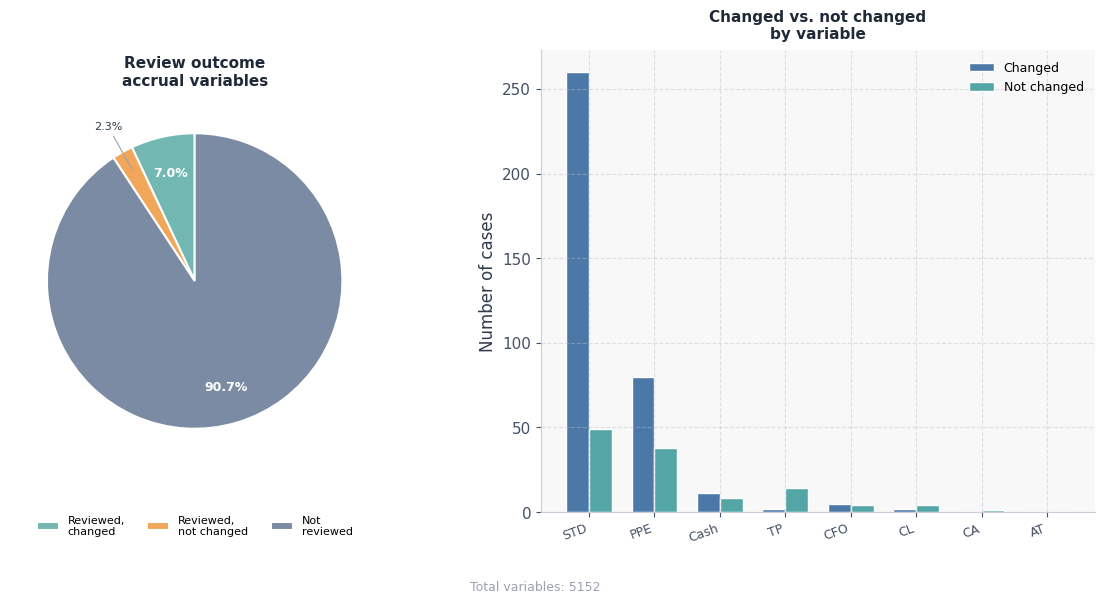

Total observations:                5152
Reviewed, changed:                360.0
Reviewed, not changed:              118
Not reviewed:                    4674.0


In [25]:
import numpy as np

# ── Konstanter ─────────────────────────────────────────────────────────────
N_COMPANIES  = 644
N_VARIABLES  = 8
TOTAL_OBS    = N_COMPANIES * N_VARIABLES  # 5,152

VARIABLES = ['ACT', 'CHE', 'LCT', 'STD', 'TXP', 'PPEGT', 'AT', 'OANCF']

VAR_LABELS = {
    'ACT':   'CA',
    'CHE':   'Cash',
    'LCT':   'CL',
    'STD':   'STD',
    'TXP':   'TP',
    'PPEGT': 'PPE',
    'AT':    'AT',
    'OANCF': 'CFO',
}

N_VARIABLES  = 8
TOTAL_OBS    = N_COMPANIES * N_VARIABLES  # 5,152
# ── Rebuild per-variable counts from JSON ──────────────────────────────────
var_counts_c  = {v: 0.0 for v in VARIABLES}
var_counts_nc = {v: 0   for v in VARIABLES}

ROOT_PATH = Path("../data/mappings/acc_mappings")
ACC_INCLUDE_FOLDERS = {"acc_mappings_cox", "acc_mappings_hex", "acc_mappings_isx",
                       "acc_mappings_obx", "acc_mappings_stx"}
ACC_TARGET_TAGS = ['R:c', 'R:nc']

def find_tags_simple(notes, target_tags):
    matched = []
    for tag in target_tags:
        pattern = r'(?<![A-Za-z:])' + re.escape(tag) + r'(?![A-Za-z:|])'
        if re.search(pattern, notes):
            matched.append(tag)
    return matched

for folder in ROOT_PATH.iterdir():
    if not folder.is_dir() or folder.name not in ACC_INCLUDE_FOLDERS:
        continue
    for jf in folder.glob('*.json'):
        try:
            data = json.loads(jf.read_text(encoding='utf-8'))
        except Exception:
            continue
        for var_obj in data.get('variables', []):
            notes    = var_obj.get('notes', '') or ''
            variable = var_obj.get('variable', '')
            if variable not in VARIABLES:
                continue
            matched = find_tags_simple(notes, ACC_TARGET_TAGS)
            if not matched:
                continue
            if 'R:c' in matched:
                var_counts_c[variable] += 1.0
            elif 'R:nc' in matched:
                var_counts_nc[variable] += 1

# ── Totaler ────────────────────────────────────────────────────────────────
sum_c_adj    = sum(var_counts_c.values())
sum_nc       = sum(var_counts_nc.values())
not_reviewed = TOTAL_OBS - sum_c_adj - sum_nc

# ── Diagram data ───────────────────────────────────────────────────────────
pie1_values = [sum_c_adj, sum_nc, not_reviewed]
pie1_labels = ['Reviewed,\nchanged', 'Reviewed,\nnot changed', 'Not\nreviewed']
pie1_colors = [PALETTE['green'], PALETTE['orange'], PALETTE['slate']]

var_totals  = {v: var_counts_c[v] + var_counts_nc[v] for v in VARIABLES}
var_sorted  = sorted(var_totals, key=var_totals.get, reverse=True)

r_c_per_var  = pd.Series({v: var_counts_c[v]  for v in var_sorted})
r_nc_per_var = pd.Series({v: var_counts_nc[v] for v in var_sorted})

# ── Figure — 1x2 layout ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6),
                         gridspec_kw={'width_ratios': [1, 1.5], 'wspace': 0.35})
fig.patch.set_facecolor('white')

threshold = 0.03

# ── Plot 1 ─────────────────────────────────────────────────────────────────
result1 = axes[0].pie(pie1_values, colors=pie1_colors, autopct=None, labels=None,
                      startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
wedges1 = result1[0]
total1  = sum(pie1_values)
for wedge, val in zip(wedges1, pie1_values):
    pct   = val / total1
    angle = (wedge.theta1 + wedge.theta2) / 2
    rad   = np.deg2rad(angle)
    if pct >= threshold:
        t = axes[0].text(0.75*np.cos(rad), 0.75*np.sin(rad), f'{pct*100:.1f}%',
                         ha='center', va='center', fontsize=9,
                         fontweight='semibold', zorder=10)
        t.set_color('white')
    else:
        axes[0].annotate(
            f'{pct*100:.1f}%',
            xy=(0.85*np.cos(rad), 0.85*np.sin(rad)),
            xytext=(1.2*np.cos(rad), 1.2*np.sin(rad)),
            ha='center', va='center', fontsize=8, color='#2f3b4a',
            arrowprops=dict(arrowstyle='-', color='#9ca3af', lw=0.8),
        )
axes[0].legend(labels=pie1_labels, loc='lower center', bbox_to_anchor=(0.5, -0.22),
               ncol=3, fontsize=8, frameon=False)
axes[0].set_title('Review outcome\naccrual variables', fontsize=11,
                  fontweight='bold', color='#1f2937', pad=8)
axes[0].set_facecolor('white')

# ── Plot 2 — Bar chart ─────────────────────────────────────────────────────
x     = np.arange(len(var_sorted))
width = 0.35
axes[1].bar(x - width/2, r_c_per_var.values,  width, label='Changed',
            color=PALETTE['blue'], edgecolor='white')
axes[1].bar(x + width/2, r_nc_per_var.values, width, label='Not changed',
            color=PALETTE['teal'], edgecolor='white')
style_axis(axes[1], '', ylabel='Number of cases')
axes[1].set_facecolor('#f8f8f8')
axes[1].set_title('Changed vs. not changed\nby variable', fontsize=11,
                  fontweight='bold', color='#1f2937', pad=8)
axes[1].set_xticks(x)
axes[1].set_xticklabels([VAR_LABELS.get(v, v) for v in var_sorted],
                         rotation=20, ha='right', fontsize=9)
axes[1].legend(fontsize=9)

fig.text(0.5, -0.02, f'Total variables: {TOTAL_OBS}',
         ha='center', fontsize=9, color='#9ca3af')
fig.savefig(OUT_DIR / '8_review_pie_analysis_acc.png', dpi=150,
            bbox_inches='tight', facecolor='white')
plt.show()

# ── Print summary ──────────────────────────────────────────────────────────
print(f"Total observations:              {TOTAL_OBS:>6}")
print(f"Reviewed, changed:               {sum_c_adj:>6}")
print(f"Reviewed, not changed:           {sum_nc:>6}")
print(f"Not reviewed:                    {not_reviewed:>6}")

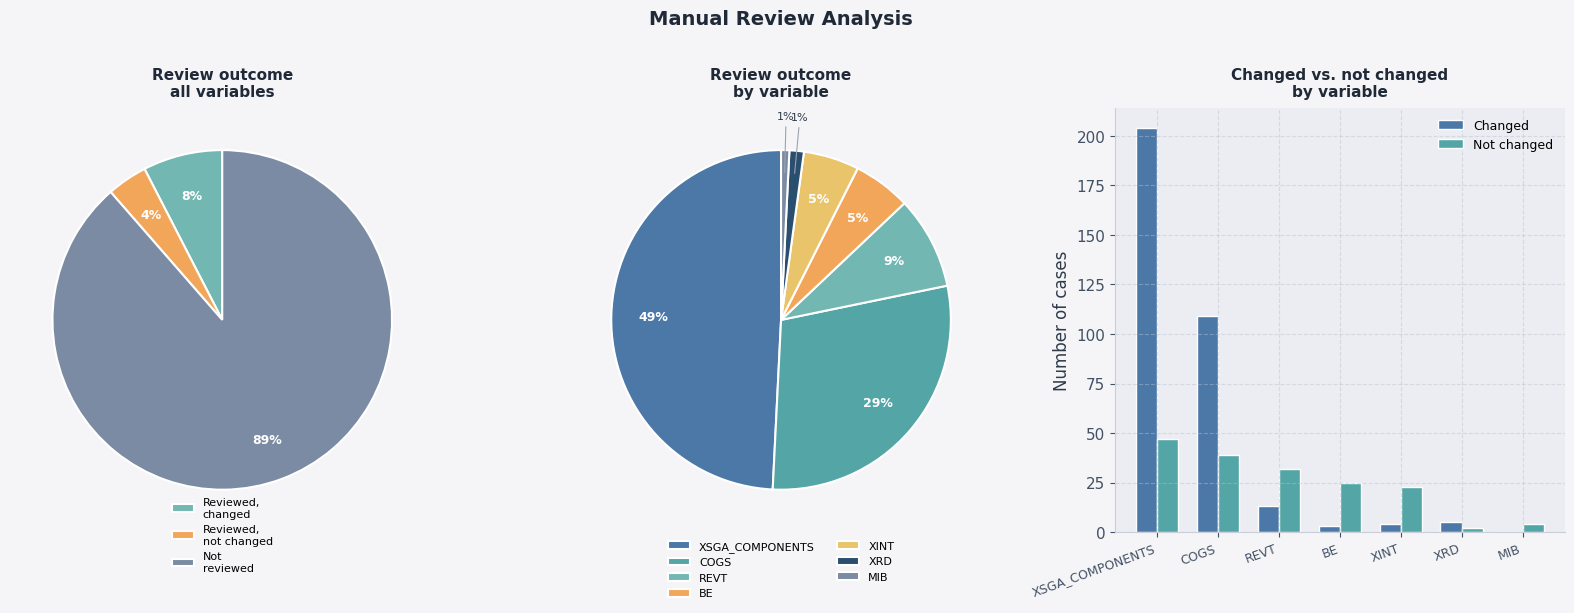

Total observations:                4466
Reviewed, changed (adj):            338
Reviewed, not changed:              172
Not reviewed:                      3956


In [127]:
import numpy as np
from matplotlib import gridspec

# ── Konstanter ─────────────────────────────────────────────────────────────
N_COMPANIES  = 638
N_VARIABLES  = 7
TOTAL_OBS    = N_COMPANIES * N_VARIABLES  # 4,466

MISSING_TAGS = ['CR:c|low|missing', 'CR:c|high|missing', 'CR:c||missing']
VARIABLES    = ['REVT', 'COGS', 'XSGA_COMPONENTS', 'XRD', 'XINT', 'BE', 'MIB']

# ── Rebuild per-variable counts from JSON ──────────────────────────────────
var_counts_c  = {v: 0.0 for v in VARIABLES}
var_counts_nc = {v: 0   for v in VARIABLES}

ROOT_PATH = Path("../data/mappings/prof_mappings")

for folder in ROOT_PATH.iterdir():
    if not folder.is_dir() or folder.name not in INCLUDE_FOLDERS:
        continue
    for jf in folder.rglob('*.json'):
        try:
            data = json.loads(jf.read_text(encoding='utf-8'))
        except Exception:
            continue
        for var_obj in data.get('variables', []):
            notes    = var_obj.get('notes', '') or ''
            variable = var_obj.get('variable', '')
            if variable not in VARIABLES:
                continue
            matched = find_tags(notes, TARGET_TAGS)
            if not matched:
                continue
            matched = apply_priority(matched)
            for tag in matched:
                is_missing = tag in MISSING_TAGS
                if tag.startswith('CR:c') or tag in ('R:c', 'OI:c'):
                    var_counts_c[variable] += 0.5 if is_missing else 1.0
                elif tag in ('CR:nc', 'R:nc', 'OI:nc'):
                    var_counts_nc[variable] += 1

var_counts_c = {v: round(val) for v, val in var_counts_c.items()}

# ── Totaler ────────────────────────────────────────────────────────────────
sum_c_adj    = sum(var_counts_c.values())
sum_nc       = sum(var_counts_nc.values())
not_reviewed = TOTAL_OBS - sum_c_adj - sum_nc

# ── Diagram data ───────────────────────────────────────────────────────────
pie1_values = [sum_c_adj, sum_nc, not_reviewed]
pie1_labels = ['Reviewed,\nchanged', 'Reviewed,\nnot changed', 'Not\nreviewed']
pie1_colors = [PALETTE['green'], PALETTE['orange'], PALETTE['slate']]

var_totals  = {v: var_counts_c[v] + var_counts_nc[v] for v in VARIABLES}
var_sorted  = sorted(var_totals, key=var_totals.get, reverse=True)
pie2_values = [var_totals[v] for v in var_sorted]
pie2_labels = var_sorted
pie2_colors = [PALETTE['blue'], PALETTE['teal'], PALETTE['green'],
               PALETTE['orange'], PALETTE['gold'], PALETTE['navy'],
               PALETTE['slate']][:len(var_sorted)]

r_c_per_var  = pd.Series({v: var_counts_c[v]  for v in var_sorted})
r_nc_per_var = pd.Series({v: var_counts_nc[v] for v in var_sorted})

# ── Figure ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 6))

threshold = 0.03

# ── Plot 1 ─────────────────────────────────────────────────────────────────
result1 = axes[0].pie(pie1_values, colors=pie1_colors, autopct=None, labels=None,
                      startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
wedges1 = result1[0]
total1  = sum(pie1_values)
for wedge, val in zip(wedges1, pie1_values):
    pct   = val / total1
    angle = (wedge.theta1 + wedge.theta2) / 2
    rad   = np.deg2rad(angle)
    if pct >= threshold:
        t = axes[0].text(0.75*np.cos(rad), 0.75*np.sin(rad), f'{pct*100:.0f}%',
                         ha='center', va='center', fontsize=9,
                         fontweight='semibold', zorder=10)
        t.set_color('white')
    else:
        axes[0].annotate(
            f'{pct*100:.0f}%',
            xy=(0.85*np.cos(rad), 0.85*np.sin(rad)),
            xytext=(1.2*np.cos(rad), 1.2*np.sin(rad)),
            ha='center', va='center', fontsize=8, color='#2f3b4a',
            arrowprops=dict(arrowstyle='-', color='#9ca3af', lw=0.8),
        )
axes[0].legend(labels=pie1_labels, loc='lower center', bbox_to_anchor=(0.5, -0.12),
               ncol=1, fontsize=8, frameon=False)
axes[0].set_title('Review outcome\nall variables', fontsize=11,
                  fontweight='bold', color='#1f2937', pad=8)

# ── Plot 2 ─────────────────────────────────────────────────────────────────
result2 = axes[1].pie(pie2_values, colors=pie2_colors, autopct=None, labels=None,
                      startangle=90,  
                      wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
wedges2 = result2[0]
total2  = sum(pie2_values)
for wedge, val in zip(wedges2, pie2_values):
    pct   = val / total2
    angle = (wedge.theta1 + wedge.theta2) / 2
    rad   = np.deg2rad(angle)
    if pct >= threshold:
        t = axes[1].text(0.75*np.cos(rad), 0.75*np.sin(rad), f'{pct*100:.0f}%',
                         ha='center', va='center', fontsize=9, fontweight='semibold', zorder=10)
        t.set_color('white')
    else:
        axes[1].annotate(
            f'{pct*100:.0f}%',
            xy=(0.85*np.cos(rad), 0.85*np.sin(rad)),
            xytext=(1.2*np.cos(rad), 1.2*np.sin(rad)),
            ha='center', va='center', fontsize=8, color='#2f3b4a',
            arrowprops=dict(arrowstyle='-', color='#9ca3af', lw=0.8),
        )
axes[1].legend(labels=pie2_labels, loc='lower center', bbox_to_anchor=(0.5, -0.18),
               ncol=2, fontsize=8, frameon=False)
axes[1].set_title('Review outcome\nby variable', fontsize=11,
                  fontweight='bold', color='#1f2937', pad=8)

# ── Plot 3 ─────────────────────────────────────────────────────────────────
x     = np.arange(len(var_sorted))
width = 0.35
axes[2].bar(x - width/2, r_c_per_var.values,  width, label='Changed',
            color=PALETTE['blue'], edgecolor='white')
axes[2].bar(x + width/2, r_nc_per_var.values, width, label='Not changed',
            color=PALETTE['teal'], edgecolor='white')
style_axis(axes[2], '', ylabel='Number of cases')
axes[2].set_title('Changed vs. not changed\nby variable', fontsize=11,
                  fontweight='bold', color='#1f2937', pad=8)
axes[2].set_xticks(x)
axes[2].set_xticklabels(var_sorted, rotation=20, ha='right', fontsize=9)
axes[2].legend(fontsize=9)

fig.suptitle('Manual Review Analysis', fontsize=14, fontweight='bold', color='#1f2937', y=1.01)
fig.tight_layout()
fig.savefig(OUT_DIR / '8_review_pie_analysis.png', dpi=150)
plt.show()

# ── Print summary ──────────────────────────────────────────────────────────
print(f"Total observations:              {TOTAL_OBS:>6}")
print(f"Reviewed, changed (adj):         {sum_c_adj:>6}")
print(f"Reviewed, not changed:           {sum_nc:>6}")
print(f"Not reviewed:                    {not_reviewed:>6}")